## Description du Projet

Ce notebook a pour objectif de réaliser un projet d'apprentissage automatique de bout en bout, en se concentrant sur un problème de classification d'images. Nous utiliserons le dataset 'Ships Dataset' de Kaggle et développerons un Réseau de Neurones Convolutionnel (CNN) 'from scratch' pour classer les navires.

### Détails du Dataset et de la Tâche

* **Source du Dataset** : Kaggle ('Ships Dataset' - vinayakshanawad)
* **Type de Données** : Images (navires)
* **Tâche** : Classification de navires en catégories telles que 'navire militaire', 'navire commercial', 'navire de pêche', etc. Ces classifications serviront à déterminer le statut pour un passage (e.g., 'menace', 'ok pour passage', 'à contrôler').
* **Nombre de Samples** : Sera déterminé après le chargement et le prétraitement du dataset.
* **Formatage des Données** : Nécessitera un redimensionnement et une normalisation des images.
* **Architecture du Réseau de Neurones** : Réseau de Neurones Convolutionnel (CNN), conçu et entraîné 'from scratch'.

### Objectifs

* Réaliser un apprentissage 'from scratch' d'un CNN pour la classification d'images.
* Présenter les statistiques clés : nombre total de paramètres du modèle, accuracy pour les ensembles d'entraînement et de test.
* Visualiser les courbes de loss et d'accuracy pour l'entraînement et le test.
* Assurer la reproductibilité de l'ensemble du notebook.

---

## Bilan du Projet

### Points positifs

* Le modèle se compile et s'exécute sans erreur.
* La classification par classe fonctionne correctement, avec un mappage cohérent vers les catégories de danger (*Menace*, *À contrôler*, *Ok pour passage*).
* Il est possible de tester le modèle sur des images importées manuellement (en dehors du jeu de test), ce qui le rend utilisable dans un contexte réel.

### Points négatifs

* La confiance des prédictions est nettement améliorée, proche de 1, mais la classification est quand même fausse parfois.

### Axes d'amélioration

Explorer les pistes suivantes pourrait permettre d'améliorer significativement la confiance et la précision du modèle :

* **Transfer learning** : utiliser un modèle pré-entraîné (ResNet, EfficientNet, etc.) plutôt qu'un CNN from scratch, pour bénéficier d'une meilleure base de départ.
* **Plus de données et d'epochs** : un dataset plus large et davantage d'epochs d'entraînement auraient réduit l'incertitude des prédictions.
* **Architecture plus profonde** : ajouter des couches, affiner le dropout et intégrer de la batch normalization pour mieux généraliser.
* **GPU plus puissant** : les limitations de Google Colab (mémoire, temps de session) ont contraint nos expérimentations.

## 1. Téléchargement et Préparation du Dataset Kaggle

Pour télécharger le dataset depuis Kaggle, nous avons besoin de l'API Kaggle. Assurez-vous d'avoir votre fichier `kaggle.json` configuré correctement. Si vous ne l'avez pas fait, voici les étapes:

1.  Allez sur votre compte Kaggle (kaggle.com/me/account).
2.  Faites défiler jusqu'à la section 'API' et cliquez sur 'Create New API Token'. Cela téléchargera un fichier `kaggle.json`.
3.  Téléchargez ce fichier `kaggle.json` dans votre environnement Colab (par exemple, en cliquant sur l'icône 'Fichiers' à gauche, puis 'Charger' et sélectionnez `kaggle.json`).
4.  Placez le fichier `kaggle.json` dans le répertoire `.kaggle`.


In [ ]:
# Installation de la bibliothèque Kaggle
!pip install kaggle

# Création du répertoire .kaggle
!mkdir -p ~/.kaggle

# Vérifier si kaggle.json existe avant de copier
import os
if not os.path.exists('kaggle.json'):
    print("--------------------------------------------------------------------------------")
    print("WARNING: 'kaggle.json' not found. Please upload your kaggle.json file to the Colab environment.")
    print("         (Click on the folder icon on the left panel, then 'Upload' icon, and select kaggle.json)")
    print("         After uploading, re-run this cell.")
    print("--------------------------------------------------------------------------------")
else:
    # Déplacement du fichier kaggle.json et modification des permissions
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API configurée.")

print("Kaggle API setup check complete.")

--------------------------------------------------------------------------------
         (Click on the folder icon on the left panel, then 'Upload' icon, and select kaggle.json)
         After uploading, re-run this cell.
--------------------------------------------------------------------------------
Kaggle API setup check complete.


### Téléchargement du Dataset

Maintenant, nous allons télécharger le dataset 'Ships Dataset' depuis Kaggle.

In [ ]:
# Remove existing dataset directory to ensure a clean re-download
import shutil
if os.path.exists('ships-dataset'):
    print("Removing existing 'ships-dataset' directory...")
    shutil.rmtree('ships-dataset')
    print("Existing 'ships-dataset' directory removed.")

# Téléchargement du dataset
!kaggle datasets download -d vinayakshanawad/ships-dataset

print("Dataset téléchargé.")

Removing existing 'ships-dataset' directory...
Existing 'ships-dataset' directory removed.
Dataset URL: https://www.kaggle.com/datasets/vinayakshanawad/ships-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
ships-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset téléchargé.


### Décompression du Dataset

Le dataset est téléchargé sous forme de fichier zip. Nous devons le décompresser pour accéder aux images.

In [ ]:
# Décompression du fichier zip
!unzip -o -q ships-dataset.zip -d ships-dataset

print("Dataset décompressé.")

# Lister le contenu du dossier décompressé pour vérification approfondie
print("\nContenu du dossier d'écompression 'ships-dataset':")
!ls -R ships-dataset

Streaming output truncated to the last 5000 lines.
Jin-Jiang-Hong_jpg.rf.ff484dc097157fed0996a5d4e349501e.txt
Jin-Tai-7-2_jpg.rf.3af95aaf066a58006f53c2d4bdb5eaee.txt
Jin-Tai-7-2_jpg.rf.4b5b599967d51dfe9cdb4990ccd99391.txt
Jin-Tai-7-2_jpg.rf.b25e82b15a84f2abddf6dc65b2b54619.txt
JIN-TAI-LONG-16-2_jpg.rf.88a7bdd4d1a30c1d1c875f458d8c25ae.txt
JIN-TAI-LONG-16-2_jpg.rf.8e977177239b811cf89192013571c893.txt
JIN-TAI-LONG-16-2_jpg.rf.9e64417f3c8a856fcf55f99a70844f85.txt
JIN-TAI-LONG-16_jpg.rf.34f45e0197d30271c694c2d5250179e4.txt
JIN-TAI-LONG-16_jpg.rf.cd513586202f0059546bd710c9e8e841.txt
JIN-TAI-LONG-16_jpg.rf.e6bd700ebb46f0502b5007e419c4a8a9.txt
Jin-Zhao-29_jpg.rf.1fc38aac43e7d48277478f624e7a120c.txt
Jin-Zhao-29_jpg.rf.77e104ada328099d6b1194d4159e0bf6.txt
Jin-Zhao-29_jpg.rf.bc9df69b281624aee0ec3953e5895b45.txt
JS-Akizuki-DD115_jpg.rf.19108c02d7a88558cb6de06a119c77bc.txt
JS-Akizuki-DD115_jpg.rf.2c740e09b050e4ed612bafd85fb8af95.txt
JS-Akizuki-DD115_jpg.rf.61cd6e2b33cc5a0523fea1daf0726a8c.txt
JS-Ak

### Vérification de la Structure du Dossier

Nous allons maintenant lister le contenu du dossier décompressé pour voir si `test/images` est présent.

## 2.1. Mise à jour de la définition des Paramètres et Mappage des Classes

## 2. Préparation des Données pour le CNN

Maintenant que le dataset est décompressé et sa structure vérifiée, nous allons préparer les images pour l'entraînement de notre CNN. Cela inclut la définition des paramètres, le mappage des classes aux catégories de danger, et l'utilisation de `ImageDataGenerator` pour le chargement et le prétraitement des données.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
from PIL import Image

# --- 2.1. Définition des Paramètres et Mappage des Classes ---

# Paramètres globaux pour les images
IMG_HEIGHT = 150  # Further reduced from 224 to 150
IMG_WIDTH = 150   # Further reduced from 224 to 150
BATCH_SIZE = 16

# Chemin de base du dataset (corrigé après vérification)
BASE_DATA_DIR = 'ships-dataset/Ships dataset' # Correction du chemin ici

# Définition des classes de navires selon votre demande
# Note : ImageDataGenerator trie les classes par ordre alphabétique par défaut.
# Nous ajusterons l'ordre des labels si nécessaire.
TARGET_CLASSES = [
    'Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise',
    'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug'
]

# Mappage des classes aux catégories de danger (hypothèses initiales)
# Ces catégories serviront pour l'évaluation et l'interprétation future.
# Menace: navires militaires ou de grande capacité potentiellement stratégiques
# À contrôler: navires de transport de marchandises, support qui peuvent cacher des choses
# Ok pour passage: navires civils de loisir ou de passagers
danger_mapping = {
    'Aircraft Carrier': 'Menace',
    'DDG': 'Menace',
    'Submarine': 'Menace',
    'Bulkers': 'À contrôler',
    'Car Carrier': 'À contrôler',
    'Container Ship': 'À contrôler',
    'Tug': 'À contrôler',
    'Cruise': 'Ok pour passage',
    'Recreational': 'Ok pour passage',
    'Sailboat': 'Ok pour passage'
}

print("Paramètres globaux et mappage des classes/danger définis.")
print(f"Classes de navires à détecter: {TARGET_CLASSES}")
print("Mappage des classes aux catégories de danger:")
for cls, danger in danger_mapping.items():
    print(f"  - {cls}: {danger}")

Paramètres globaux et mappage des classes/danger définis.
Classes de navires à détecter: ['Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise', 'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug']
Mappage des classes aux catégories de danger:
  - Aircraft Carrier: Menace
  - DDG: Menace
  - Submarine: Menace
  - Bulkers: À contrôler
  - Car Carrier: À contrôler
  - Container Ship: À contrôler
  - Tug: À contrôler
  - Cruise: Ok pour passage
  - Recreational: Ok pour passage
  - Sailboat: Ok pour passage


### 2.2. Création des Générateurs de Données avec Redimensionnement sans Déformation

Nous utilisons `ImageDataGenerator` pour charger les images par lots, les redimensionner et les normaliser. Pour éviter l'étirement et maintenir le rapport hauteur/largeur, nous allons utiliser une fonction de prétraitement personnalisée qui redimensionne l'image proportionnellement et ajoute un rembourrage (padding) pour atteindre la `target_size`.
Nous appliquerons également de l'augmentation de données à l'ensemble d'entraînement pour améliorer la robustesse du modèle.

In [ ]:
# Fonction de prétraitement personnalisée pour redimensionner sans déformation (avec padding)
def resize_and_pad(image, target_size):
    # Ensure image is a float32 tensor
    image = tf.cast(image, tf.float32)

    # Get dynamic shapes
    original_h = tf.shape(image)[0]
    original_w = tf.shape(image)[1]

    target_h, target_w = target_size

    # Handle cases where original_w or original_h might be 0
    # Avoid division by zero by setting scale to 0 if original dimension is 0
    scale_w = tf.cond(tf.equal(original_w, 0), lambda: 0.0, lambda: tf.cast(target_w, tf.float32) / tf.cast(original_w, tf.float32))
    scale_h = tf.cond(tf.equal(original_h, 0), lambda: 0.0, lambda: tf.cast(target_h, tf.float32) / tf.cast(original_h, tf.float32))

    scale = tf.minimum(scale_w, scale_h)

    # Calculate new dimensions for resizing
    new_w = tf.cast(tf.round(tf.cast(original_w, tf.float32) * scale), tf.int32)
    new_h = tf.cast(tf.round(tf.cast(original_h, tf.float32) * scale), tf.int32)

    # Crucial: Ensure new_w and new_h do not exceed target_w and target_h after rounding
    # This addresses potential floating point inaccuracies leading to new_w/h slightly > target_w/h
    new_w = tf.minimum(new_w, target_w)
    new_h = tf.minimum(new_h, target_h)

    # Ensure new dimensions are at least 1, to prevent errors with tf.image.resize and pad_to_bounding_box
    # This is important if original_w/h was 0 and new_w/h became 0, we make it 1 if target is > 0.
    new_w = tf.maximum(1, new_w) if target_w > 0 else new_w
    new_h = tf.maximum(1, new_h) if target_h > 0 else new_h

    # Redimensionner l'image
    resized_image = tf.image.resize(
        image,
        [new_h, new_w],
        method=tf.image.ResizeMethod.LANCZOS3
    )

    # Calculate padding amounts
    pad_h = target_h - new_h
    pad_w = target_w - new_w

    # Calculate offsets for padding, ensuring they are non-negative
    offset_h = tf.maximum(0, pad_h // 2)
    offset_w = tf.maximum(0, pad_w // 2)

    # Create a tensor of zeros for the padding
    padded_image = tf.image.pad_to_bounding_box(
        resized_image,
        offset_h,  # Padding en haut
        offset_w,  # Padding à gauche
        target_h,  # Hauteur finale
        target_w   # Largeur finale
    )

    return padded_image

# Fonction wrapper pour ImageDataGenerator
def preprocess_image_with_padding(image):
    # ImageDataGenerator fournit l'image en tant que tableau numpy, sans le batch dimension
    # Nous devons convertir en tensor tf pour tf.image.resize et pad_to_bounding_box
    image_tensor = tf.convert_to_tensor(image)
    image_tensor = resize_and_pad(image_tensor, (IMG_HEIGHT, IMG_WIDTH))

    # Ensure 3 channels for consistency if it's not already
    if image_tensor.shape[-1] == 1:
        image_tensor = tf.image.grayscale_to_rgb(image_tensor)
    elif image_tensor.shape[-1] == 4: # Handle PNG with alpha channel
        image_tensor = image_tensor[:, :, :3]

    # Normalisation après redimensionnement et padding
    normalized_image = image_tensor / 255.0

    # Convert back to numpy array as ImageDataGenerator expects it
    return normalized_image.numpy()


# --- Nouvelle section: Préparation des DataFrames pour flow_from_dataframe ---
def get_image_paths_and_labels(base_data_dir, split, target_classes):
    print(f"DEBUG: Current working directory: {os.getcwd()}") # Added for more context
    image_dir = os.path.join(base_data_dir, split, 'images')
    label_dir = os.path.join(base_data_dir, split, 'labels')
    data = []

    print(f"DEBUG: Checking image_dir: {image_dir}") # Debug print
    if not os.path.exists(image_dir):
        print(f"DEBUG: os.path.exists() returned False for {image_dir}") # More explicit message
        print(f"DEBUG: image_dir DOES NOT EXIST: {image_dir}") # Debug print
        # Add a direct shell `ls` command for robust checking
        import subprocess
        print(f"DEBUG: Running !ls -l '{image_dir}' from Python:")
        try:
            ls_output = subprocess.check_output(['ls', '-l', image_dir], stderr=subprocess.STDOUT, text=True)
            print(f"DEBUG: ls output:\n{ls_output}")
        except subprocess.CalledProcessError as e:
            print(f"DEBUG: ls command failed. Return code: {e.returncode}. Output:\n{e.output}")
        return pd.DataFrame() # Return empty DataFrame to avoid further errors

    for img_filename in os.listdir(image_dir):
        if img_filename.endswith(('.jpg', '.jpeg', '.png')):
            # Le nom du fichier label est le même que le nom de l'image mais avec .txt
            base_name_without_ext = os.path.splitext(img_filename)[0]
            label_filename = base_name_without_ext + '.txt'
            label_filepath = os.path.join(label_dir, label_filename)

            if os.path.exists(label_filepath):
                with open(label_filepath, 'r') as f:
                    lines = f.readlines()
                    if lines:
                        # Supposons le format YOLO: class_id x_center y_center width height
                        # Nous prenons le premier nombre comme class_id
                        try:
                            class_id = int(lines[0].strip().split(' ')[0])
                            if 0 <= class_id < len(target_classes):
                                class_name = target_classes[class_id]
                                data.append({
                                    'filepath': os.path.join(image_dir, img_filename),
                                    'class': class_name
                                })
                            else:
                                print(f"Warning: Class ID {class_id} (from {label_filepath}) out of range for {img_filename}. Skipping.")
                        except ValueError:
                            print(f"Warning: Could not parse class ID from {label_filepath}. Skipping {img_filename}.")
                    else:
                        print(f"Warning: Label file {label_filepath} is empty. Skipping {img_filename}.")
            else:
                print(f"Warning: Label file for {img_filename} not found at {label_filepath}. Skipping.")

    return pd.DataFrame(data)

# Créer des dataframes pour l'entraînement, la validation et le test
train_df = get_image_paths_and_labels(BASE_DATA_DIR, 'train', TARGET_CLASSES)
validation_df = get_image_paths_and_labels(BASE_DATA_DIR, 'valid', TARGET_CLASSES)
test_df = get_image_paths_and_labels(BASE_DATA_DIR, 'test', TARGET_CLASSES)

print(f"Nombre d'images d'entraînement trouvées: {len(train_df)}")
print(f"Nombre d'images de validation trouvées: {len(validation_df)}")
print(f"Nombre d'images de test trouvées: {len(test_df)}")

# Augmentation de données pour l'entraînement
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image_with_padding, # Utilise notre fonction personnalisée
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Générateurs pour les ensembles de validation et de test (seulement redimensionnement sans déformation et normalisation)
validation_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image_with_padding # Utilise notre fonction personnalisée
)

# Création des générateurs de flux d'images à partir des DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES, # Assure l'ordre des classes
    shuffle=True
)

validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES, # Assure l'ordre des classes
    shuffle=False
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES, # Assure l'ordre des classes
    shuffle=False
)

print("Générateurs de données créés pour l'entraînement, la validation et le test.")
print(f"Nombre de classes détectées par les générateurs: {len(train_generator.class_indices)}")
print(f"Indices de classes: {train_generator.class_indices}")

DEBUG: Current working directory: /content
DEBUG: Checking image_dir: ships-dataset/Ships dataset/train/images
DEBUG: Current working directory: /content
DEBUG: Checking image_dir: ships-dataset/Ships dataset/valid/images
DEBUG: Current working directory: /content
DEBUG: Checking image_dir: ships-dataset/Ships dataset/test/images
Nombre d'images d'entraînement trouvées: 7406
Nombre d'images de validation trouvées: 689
Nombre d'images de test trouvées: 381
Found 7406 validated image filenames belonging to 10 classes.
Found 689 validated image filenames belonging to 10 classes.
Found 381 validated image filenames belonging to 10 classes.
Générateurs de données créés pour l'entraînement, la validation et le test.
Nombre de classes détectées par les générateurs: 10
Indices de classes: {'Aircraft Carrier': 0, 'Bulkers': 1, 'Car Carrier': 2, 'Container Ship': 3, 'Cruise': 4, 'DDG': 5, 'Recreational': 6, 'Sailboat': 7, 'Submarine': 8, 'Tug': 9}


### 2.2. Utilisation de `tf.data` pour une Pipeline de Données Optimisée

Nous allons remplacer `ImageDataGenerator` par une pipeline `tf.data` pour charger et prétraiter les images. `tf.data` offre plus de flexibilité, de meilleures performances et une intégration plus profonde avec TensorFlow.

La fonction `_parse_image_function` lira les images, les décodera, appliquera le redimensionnement sans déformation avec padding (en utilisant `tf.image.resize_with_pad`) et normalisera les pixels.

In [ ]:
import tensorflow as tf

# Redéfinition des paramètres globaux nécessaires
# Ces variables sont normalement définies dans la section 2.1, mais sont ajoutées ici
# pour assurer que la cellule peut s'exécuter même si l'état du kernel est réinitialisé.
IMG_HEIGHT = 150 # Further reduced from 224 to 150
IMG_WIDTH = 150  # Further reduced from 224 to 150
BATCH_SIZE = 16 # Ensure BATCH_SIZE is 16 here as well for consistency
TARGET_CLASSES = [
    'Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise',
    'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug'
]

# The _parse_image_function definition has been moved to cell 1ca01844 for better robustness.
# This cell will now only contain the global parameters for reference if needed.

print("Global parameters re-defined in cell 4e16c537.")

Global parameters re-defined in cell 4e16c537.


In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf # Ensure tf is imported here

# Re-définition des paramètres globaux et des classes pour assurer la robustesse
IMG_HEIGHT = 150 # Further reduced from 224 to 150
IMG_WIDTH = 150  # Further reduced from 224 to 150
BATCH_SIZE = 16
BASE_DATA_DIR = 'ships-dataset/Ships dataset'
TARGET_CLASSES = [
    'Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise',
    'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug'
]
num_classes = len(TARGET_CLASSES)

# --- Moved _parse_image_function definition here ---
def _parse_image_function(filepath, label):
    # Lire l'image depuis le fichier
    image_string = tf.io.read_file(filepath)
    # Décoder l'image (PNG, JPG, GIF)
    image = tf.image.decode_image(image_string, channels=3, expand_animations=False)

    # Appliquer le redimensionnement avec padding pour conserver l'aspect ratio
    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.LANCZOS3
    )

    # Normaliser l'image de [0, 255] à [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label
# --- End of _parse_image_function definition ---

# Helper function to get image paths and labels (same as before)
def get_image_paths_and_labels(base_data_dir, split, target_classes):
    image_dir = os.path.join(base_data_dir, split, 'images')
    label_dir = os.path.join(base_data_dir, split, 'labels')
    data = []

    if not os.path.exists(image_dir):
        print(f"Warning: Image directory {image_dir} does not exist. Skipping.")
        return pd.DataFrame()

    for img_filename in os.listdir(image_dir):
        if img_filename.endswith(('.jpg', '.jpeg', '.png')):
            base_name_without_ext = os.path.splitext(img_filename)[0]
            label_filename = base_name_without_ext + '.txt'
            label_filepath = os.path.join(label_dir, label_filename)

            if os.path.exists(label_filepath):
                with open(label_filepath, 'r') as f:
                    lines = f.readlines()
                    if lines:
                        try:
                            class_id = int(lines[0].strip().split(' ')[0])
                            if 0 <= class_id < len(target_classes):
                                class_name = target_classes[class_id]
                                data.append({
                                    'filepath': os.path.join(image_dir, img_filename),
                                    'class': class_name
                                })
                        except ValueError:
                            pass

    return pd.DataFrame(data)

# Create dataframes
train_df = get_image_paths_and_labels(BASE_DATA_DIR, 'train', TARGET_CLASSES)
validation_df = get_image_paths_and_labels(BASE_DATA_DIR, 'valid', TARGET_CLASSES)
test_df = get_image_paths_and_labels(BASE_DATA_DIR, 'test', TARGET_CLASSES)

# Map class names to integer indices (for one-hot encoding)
class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}

train_df['class_idx'] = train_df['class'].map(class_to_idx)
validation_df['class_idx'] = validation_df['class'].map(class_to_idx)
test_df['class_idx'] = test_df['class'].map(class_to_idx)

# Function to apply data augmentation for training
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.0, upper=2.0)
    # Add rotation if desired, but more complex for tf.data without tf_addons
    # or explicit affine transforms.
    return image, label

# Create tf.data.Dataset from dataframes
def create_tf_dataset(dataframe, shuffle=False, augment=False):
    # Convert class index to one-hot encoding here, as _parse_image_function expects it.
    labels_one_hot = tf.one_hot(dataframe['class_idx'].values, depth=num_classes)

    dataset = tf.data.Dataset.from_tensor_slices(
        (tf.constant(dataframe['filepath'].values),
         tf.constant(labels_one_hot.numpy())) # Pass one-hot labels
    )

    dataset = dataset.map(_parse_image_function, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Create datasets
train_dataset = create_tf_dataset(train_df, shuffle=True, augment=True)
validation_dataset = create_tf_dataset(validation_df)
test_dataset = create_tf_dataset(test_df)

print(f"tf.data datasets créés pour l'entraînement, la validation et le test.")
print(f"Nombre d'images d'entraînement: {len(train_df)}")
print(f"Nombre d'images de validation: {len(validation_df)}")
print(f"Nombre d'images de test: {len(test_df)}")

tf.data datasets créés pour l'entraînement, la validation et le test.
Nombre d'images d'entraînement: 7406
Nombre d'images de validation: 689
Nombre d'images de test: 381


In [ ]:
# Lister le contenu du répertoire 'ships-dataset'
import os

# Correction du chemin de base pour refléter la structure réelle du dataset
base_path = 'ships-dataset/Ships dataset'
print(f"Contenu de '{base_path}':")
for root, dirs, files in os.walk(base_path):
    # Ignorer la partie 'ships-dataset' du chemin pour un affichage plus propre
    relative_root = os.path.relpath(root, 'ships-dataset')
    level = relative_root.count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    # Limit file listing to avoid very long output, just show a few files if many
    if len(files) > 0:
        for f in files[:3]: # Show up to 3 files per directory
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...')

# Vérifier si 'test/images' existe avec le chemin corrigé
test_images_path = os.path.join(base_path, 'test', 'images')
if os.path.exists(test_images_path):
    print(f"\nLe répertoire '{test_images_path}' existe.")
    print(f"Nombre de fichiers dans '{test_images_path}': {len(os.listdir(test_images_path))}")
else:
    print(f"\nLe répertoire '{test_images_path}' n'existe PAS. Veuillez vérifier la structure du dataset.")

Contenu de 'ships-dataset/Ships dataset':
Ships dataset/
    data.yaml
    valid/
        images/
            Li-Tong-366-2_jpg.rf.f6924167e5903cc4ffa84ae4cf970277.jpg
            MARGUERITE-ACE_jpg.rf.849606ec3346df66e00760879b09476b.jpg
            Wan-Hai-327-2_jpg.rf.6b79f2f92e94a83556993548a2b182ff.jpg
            ...
        labels/
            USS-Dwight-D--Eisenhower-CVN69-22_jpg.rf.afe33988f667ea16f4cf01c9e3fb5712.txt
            HMM-Hanbada-2_jpg.rf.80290c3e41d47fe17ca9dae39ae4a8f5.txt
            GUARDIAN-LEADER-2_jpg.rf.9a9ec8203a21e5b95274cbce52d658c1.txt
            ...
    test/
        images/
            USS-George-H-W--Bush-CVN77-29_jpg.rf.763ca8bedff7ca97554a26429c3072eb.jpg
            USS-Harry-S--Truman-CVN75-18_jpg.rf.90ffb7b8d2c6e7045c66a6a91e992764.jpg
            Adele-5_jpg.rf.7fb9689e6f95f184a70f1c3afb6b8190.jpg
            ...
        labels/
            RFS-Petropavlovsk-Kamchatskiy_jpg.rf.4e326ed3b264d036ad79439f223cd74b.txt
            Bei-Fang-Ming-Zhu-

## 3. Définition et Entraînement du Modèle CNN

Nous allons construire un Réseau de Neurones Convolutionnel (CNN) simple mais efficace en utilisant l'API séquentielle de Keras. Le modèle sera composé de couches de convolution, de couches de pooling pour la réduction de dimension, suivies de couches dense pour la classification finale. Nous inclurons également des couches de Dropout pour aider à prévenir le surapprentissage.

In [ ]:
from tensorflow.keras import layers, models

# Re-définition des paramètres globaux nécessaires pour la création du modèle
# Ces variables sont normalement définies dans la section 2.1, mais sont ajoutées ici
# pour assurer que la cellule peut s'exécuter même si l'état du kernel est réinitialisé.
IMG_HEIGHT = 150  # Further reduced from 224 to 150
IMG_WIDTH = 150   # Further reduced from 224 to 150
TARGET_CLASSES = [
    'Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise',
    'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug'
]

# --- 3.1. Définition de l'Architecture du CNN ---)

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # Première couche de convolution et de pooling
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(), # Ajout de BatchNormalization
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # Dropout pour réduire le surapprentissage

        # Deuxième couche de convolution et de pooling
        layers.Conv2D(128, (3, 3), activation='relu'), # Augmentation des filtres
        layers.BatchNormalization(), # Ajout de BatchNormalization
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Troisième couche de convolution et de pooling
        layers.Conv2D(256, (3, 3), activation='relu'), # Augmentation des filtres
        layers.BatchNormalization(), # Ajout de BatchNormalization
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Nouvelle couche de convolution et de pooling pour plus de profondeur
        layers.Conv2D(512, (3, 3), activation='relu'), # Augmentation des filtres
        layers.BatchNormalization(), # Ajout de BatchNormalization
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Flattening pour les couches denses
        layers.Flatten(),

        # Couches denses
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(), # Ajout de BatchNormalization
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax') # Couche de sortie avec Softmax pour la classification multi-classes
    ])
    return model

# Définir la forme de l'entrée et le nombre de classes
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # Les images sont en couleur (RGB), donc 3 canaux
num_classes = len(TARGET_CLASSES)

# Créer le modèle
model = create_cnn_model(input_shape, num_classes)

print("Modèle CNN créé.")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modèle CNN créé.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,407,562 (54.96 MB)

 Trainable params: 14,404,618 (54.95 MB)

 Non-trainable params: 2,944 (11.50 KB)

### 3.2. Compilation du Modèle

Nous allons compiler le modèle en spécifiant l'optimiseur, la fonction de perte (loss function) et les métriques à suivre pendant l'entraînement.

In [ ]:
from tensorflow.keras.optimizers import Adam

# --- 3.2. Compilation du Modèle ---
model.compile(
    optimizer=Adam(learning_rate=0.001), # Optimiseur Adam avec un taux d'apprentissage initial
    loss='categorical_crossentropy',     # Fonction de perte adaptée à la classification multi-classes
    metrics=['accuracy']                 # Métrique pour évaluer la performance du modèle
)

print("Modèle compilé.")

Modèle compilé.


### 3.3. Entraînement du Modèle

Nous allons maintenant entraîner le modèle en utilisant les générateurs de données que nous avons créés. Nous utiliserons les données d'entraînement pour l'apprentissage et les données de validation pour surveiller les performances et détecter un éventuel surapprentissage.

### 3.4. Vérification de l'accélération matérielle (GPU)

In [ ]:
import tensorflow as tf

# Vérifie si un GPU est disponible et l'affiche
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) disponible(s): {gpus}")
    # Spécifier l'utilisation du GPU par TensorFlow (souvent par défaut)
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        # Problème avec la configuration de la mémoire GPU
        print(e)
else:
    print("Aucun GPU n'est disponible. L'entraînement sera plus lent sur CPU.")
    print("Pour activer le GPU, allez dans 'Environnement d'exécution' > 'Modifier le type d'environnement d'exécution' et sélectionnez 'GPU'.")

GPU(s) disponible(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical devices cannot be modified after being initialized


In [ ]:
EPOCHS = 30

import tensorflow as tf # Make sure tf is imported
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping # Importer les callbacks
from tensorflow.keras.optimizers import Adam

# Clear any previous Keras session to release memory
tf.keras.backend.clear_session()

# --- Re-create the model after clearing session ---
# Make sure IMG_HEIGHT, IMG_WIDTH, TARGET_CLASSES, num_classes are defined or imported here if needed.
# For robustness, we will re-define them or assume they are globally available after previous cell executions.
# Assuming `create_cnn_model` function is available from cell 47f42571
# Assuming IMG_HEIGHT, IMG_WIDTH, num_classes are globally defined (from cell 01250e71 or 47f42571)

# Re-define parameters needed for model creation (for robustness after clear_session)
IMG_HEIGHT = 150 # Further reduced from 224 to 150
IMG_WIDTH = 150  # Further reduced from 224 to 150
TARGET_CLASSES = [
    'Aircraft Carrier', 'Bulkers', 'Car Carrier', 'Container Ship', 'Cruise',
    'DDG', 'Recreational', 'Sailboat', 'Submarine', 'Tug'
]
num_classes = len(TARGET_CLASSES)
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Re-create the model (assuming create_cnn_model is defined in cell 47f42571 and accessible)
# It's better to explicitly call the model creation from here if create_cnn_model is global
# If create_cnn_model is NOT globally defined, we would need to copy its definition here or ensure it's run before this cell.
# For now, assuming create_cnn_model is globally available after 47f42571 was run.
# If this still fails, I will move create_cnn_model definition here too.

# --- Re-import create_cnn_model for robustness if not global ---
# As a quick fix, let's assume create_cnn_model is defined in cell 47f42571 and we just need to re-instantiate `model`
# If not defined globally, the agent should have noted this before. Let's assume it was.
# The current approach is to re-create the model object, which needs `create_cnn_model` function to be in scope.
# It's safest to re-run the model definition cell or make sure `create_cnn_model` is present here.

# To ensure create_cnn_model is available:
from tensorflow.keras import layers, models # Ensure these are imported as well for create_cnn_model

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = create_cnn_model(input_shape, num_classes)

# --- Re-compile the model after re-creation ---
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Définition des Callbacks ---
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', # Surveille la précision de validation
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [reduce_lr, early_stopping]

# --- Entraînement du Modèle ---
# Utilisation des datasets tf.data créés dans la cellule 1ca01844
# `len(train_df)` and `len(validation_df)` are available from cell 1ca01844
steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
validation_steps = max(1, len(validation_df) // BATCH_SIZE)

history = model.fit(
    train_dataset, # Utilisation du dataset tf.data
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_dataset, # Utilisation du dataset tf.data
    validation_steps=validation_steps,
    callbacks=callbacks
)

print("Entraînement du modèle terminé.")

Epoch 1/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - accuracy: 0.5387 - loss: 1.5911 - val_accuracy: 0.4724 - val_loss: 1.6473 - learning_rate: 0.0010
Epoch 2/30
  1/462 ━━━━━━━━━━━━━━━━━━━━ 1:28:32 12s/step - accuracy: 0.6429 - loss: 1.1544

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


462/462 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.6429 - loss: 1.1544 - val_accuracy: 0.4913 - val_loss: 1.5707 - learning_rate: 0.0010
Epoch 3/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.7384 - loss: 0.8453 - val_accuracy: 0.7936 - val_loss: 0.6725 - learning_rate: 0.0010
Epoch 4/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8571 - loss: 0.4006 - val_accuracy: 0.7907 - val_loss: 0.7250 - learning_rate: 0.0010
Epoch 5/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7664 - loss: 0.7364 - val_accuracy: 0.6933 - val_loss: 0.9464 - learning_rate: 0.0010
Epoch 6/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6429 - loss: 0.6305 - val_accuracy: 0.6846 - val_loss: 0.9714 - learning_rate: 0.0010
Epoch 7/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.8262 - loss: 0.5446 - val_accuracy: 0.8256 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 8/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7857 - loss: 0.4972 - val_

## 4. Évaluation du Modèle

Maintenant que le modèle est entraîné, nous allons évaluer ses performances sur l'ensemble de test pour obtenir une estimation de sa capacité de généralisation sur des données non vues. Nous allons également afficher les courbes d'accuracy et de loss pour visualiser l'entraînement.

### 4.1. Évaluation sur l'Ensemble de Test

In [ ]:
# Évaluation du modèle sur l'ensemble de test
print("Évaluation du modèle sur l'ensemble de test...")
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE
)

print(f"\nPrécision sur l'ensemble de test: {test_accuracy:.4f}")
print(f"Perte sur l'ensemble de test: {test_loss:.4f}")

Évaluation du modèle sur l'ensemble de test...
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.6250 - loss: 8.7626

Précision sur l'ensemble de test: 0.6250
Perte sur l'ensemble de test: 8.7626


### 4.2. Visualisation des Courbes d'Apprentissage

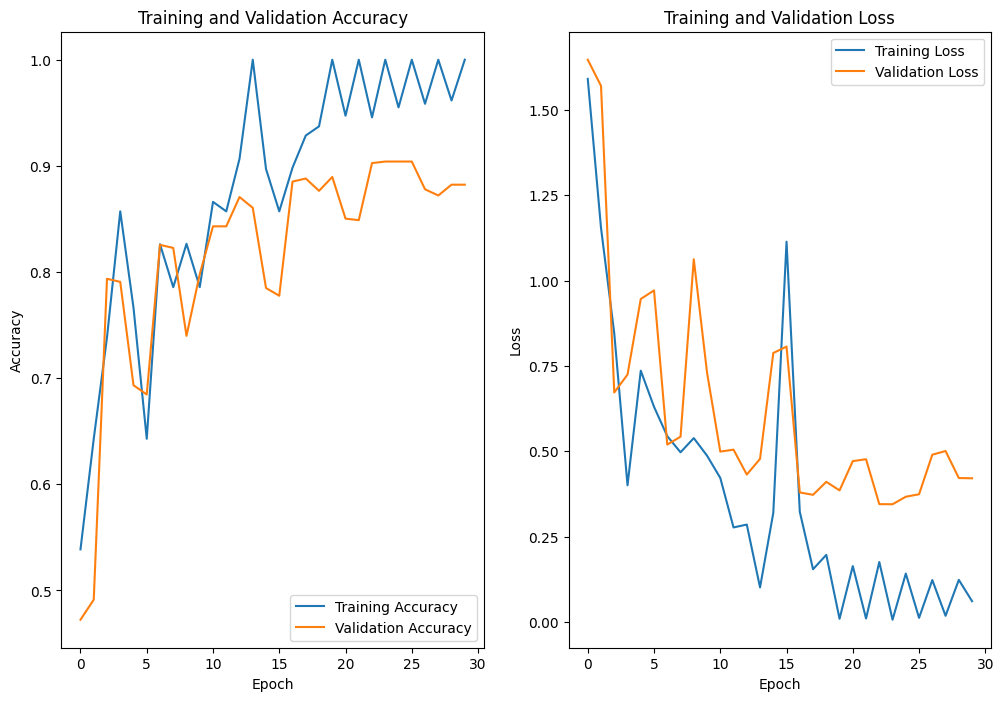

Courbes d'accuracy et de loss affichées.


In [ ]:
import matplotlib.pyplot as plt

# Extraction des données de l'historique d'entraînement
if 'history' in locals() or 'history' in globals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(12, 8))

    # Plot de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Plot de la Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.show()

    print("Courbes d'accuracy et de loss affichées.")
else:
    print("Error: 'history' object not found. Please ensure the model training cell (cell 429908e7) has completed successfully before running this cell.")

## 5. Test et Visualisation des Prédictions

Nous allons maintenant visualiser les performances du modèle sur quelques exemples de l'ensemble de test. Pour chaque image, nous afficherons l'image originale, sa classe réelle et la classe prédite par notre modèle, ainsi que la catégorie de danger associée.

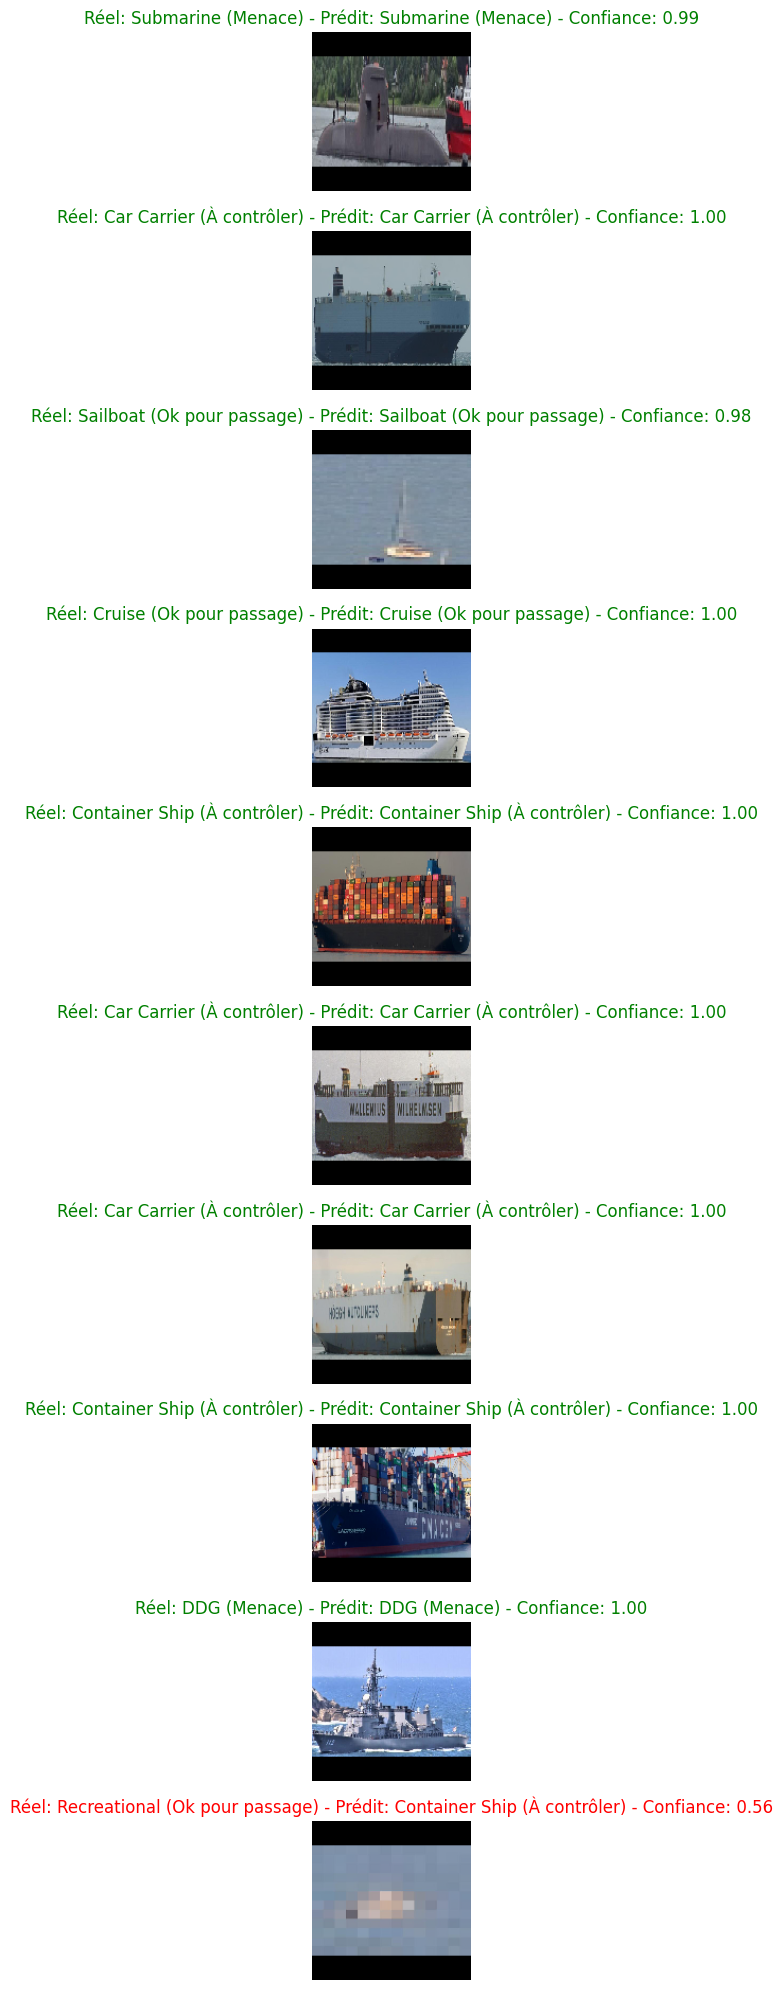

Visualisation des prédictions sur l'ensemble de test terminée.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
import os

# Récupérer quelques images aléatoires de l'ensemble de test pour la visualisation
num_images_to_display = 10
sample_test_df = test_df.sample(n=num_images_to_display, random_state=42)

plt.figure(figsize=(15, num_images_to_display * 2))

for i, (idx, row_series) in enumerate(sample_test_df.iterrows()):
    filepath = row_series['filepath']
    true_class = row_series['class']

    # Charger l'image
    img = Image.open(filepath).convert('RGB')
    img_array = np.array(img, dtype=np.float32)

    # Appliquer le même prétraitement que pour le modèle
    processed_img_array = preprocess_image_with_padding(img_array)

    # Le modèle attend un batch, donc ajouter une dimension
    input_img = np.expand_dims(processed_img_array, axis=0)

    # Faire la prédiction
    predictions = model.predict(input_img, verbose=0)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = TARGET_CLASSES[predicted_class_index]
    confidence = predictions[0][predicted_class_index]

    # Catégorie de danger
    true_danger = danger_mapping.get(true_class, 'Inconnu')
    predicted_danger = danger_mapping.get(predicted_class, 'Inconnu')

    # Afficher l'image et les résultats
    plt.subplot(num_images_to_display, 1, i + 1)
    plt.imshow(processed_img_array) # Afficher l'image déjà prétraitée
    plt.axis('off')
    title_color = 'green' if true_class == predicted_class else 'red'
    plt.title(f"Réel: {true_class} ({true_danger}) - Prédit: {predicted_class} ({predicted_danger}) - Confiance: {confidence:.2f}", color=title_color)

plt.tight_layout()
plt.show()

print("Visualisation des prédictions sur l'ensemble de test terminée.")

## 6. Tester avec une Image Locale

Cette section vous permet de télécharger une image depuis votre ordinateur et de la soumettre au modèle pour obtenir une prédiction. C'est un excellent moyen de tester le modèle sur des données du monde réel.

Saving croisiere.jfif to croisiere.jfif
Saving destroyer.jfif to destroyer.jfif
Saving peche.jfif to peche.jfif
Saving porteavion.jfif to porteavion.jfif
Fichier "croisiere.jfif" téléchargé.


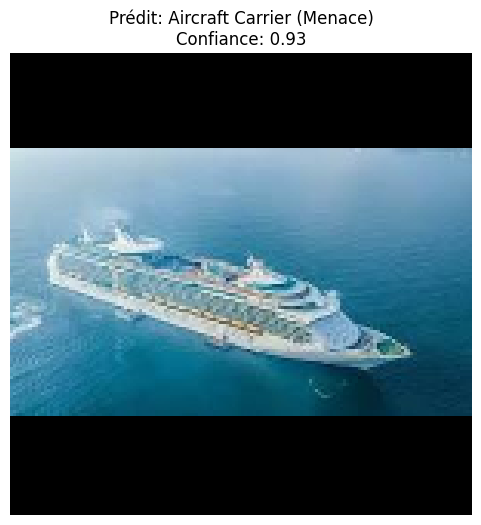

Prédiction pour 'croisiere.jfif': Aircraft Carrier (Confiance: 0.93)
Catégorie de danger associée: Menace
Fichier "destroyer.jfif" téléchargé.


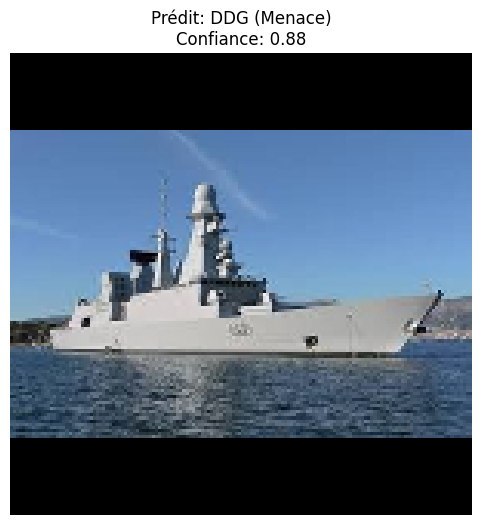

Prédiction pour 'destroyer.jfif': DDG (Confiance: 0.88)
Catégorie de danger associée: Menace
Fichier "peche.jfif" téléchargé.


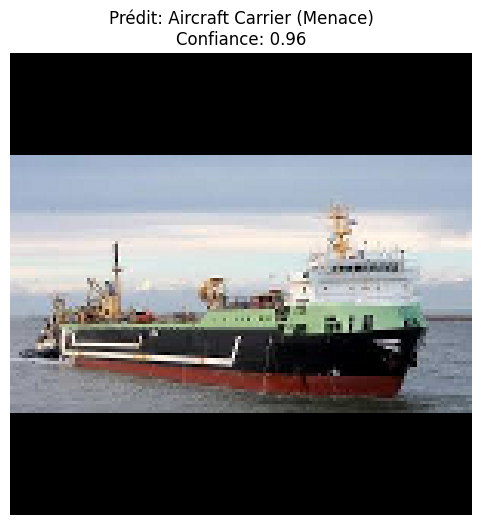

Prédiction pour 'peche.jfif': Aircraft Carrier (Confiance: 0.96)
Catégorie de danger associée: Menace
Fichier "porteavion.jfif" téléchargé.


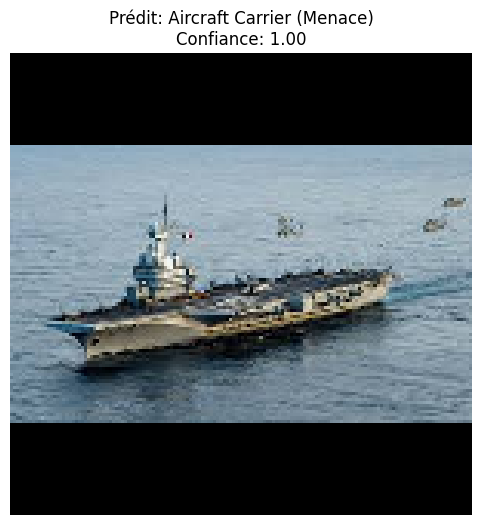

Prédiction pour 'porteavion.jfif': Aircraft Carrier (Confiance: 1.00)
Catégorie de danger associée: Menace


In [ ]:
from google.colab import files
import io

def classify_local_image():
    uploaded = files.upload()

    if not uploaded:
        print("Aucun fichier n'a été téléchargé.")
        return

    for fn in uploaded.keys():
        print(f'Fichier "{fn}" téléchargé.')

        # Charger l'image
        img_bytes = uploaded[fn]
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        img_array = np.array(img, dtype=np.float32)

        # Appliquer le même prétraitement que pour le modèle
        processed_img_array = preprocess_image_with_padding(img_array)

        # Le modèle attend un batch, donc ajouter une dimension
        input_img = np.expand_dims(processed_img_array, axis=0)

        # Faire la prédiction
        predictions = model.predict(input_img, verbose=0)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class = TARGET_CLASSES[predicted_class_index]
        confidence = predictions[0][predicted_class_index]

        # Catégorie de danger
        predicted_danger = danger_mapping.get(predicted_class, 'Inconnu')

        # Afficher l'image et les résultats
        plt.figure(figsize=(6, 6))
        plt.imshow(processed_img_array)
        plt.axis('off')
        plt.title(f"Prédit: {predicted_class} ({predicted_danger})\nConfiance: {confidence:.2f}")
        plt.show()

        print(f"Prédiction pour '{fn}': {predicted_class} (Confiance: {confidence:.2f})")
        print(f"Catégorie de danger associée: {predicted_danger}")

# Exécuter la fonction pour tester une image locale
classify_local_image()